### Prosody-Controlled Speech Synthesis with FastPitch

Short Description
This implementation demonstrates paralinguistic control in text-to-speech synthesis using Mozilla TTS's FastPitch model. It generates speech with adjustable pitch, speed, and energy parameters, provides real-time audio playback, and visualizes both the synthesized output and reference pitch contours for prosody analysis.

Key Libraries Used

    TTS: Mozilla's text-to-speech engine (FastPitch model)

    torchaudio: Audio processing and pitch extraction

    sounddevice: Real-time audio playback

    matplotlib: Prosody visualization

    torch: GPU acceleration handling

Code Logic and Flow

High-Level Overview
The workflow initializes a FastPitch TTS model, generates speech with user-controlled prosodic parameters (pitch, speed, energy), plays the audio instantly, then creates comparative visualizations of the synthesized waveform, spectrogram, and reference pitch contour when available.

Visual FlowChart:

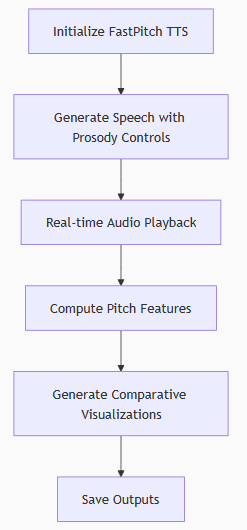

Step-by-Step Code Breakdown

1. Model Initialization

    Automatically detects GPU availability

    Loads FastPitch model pre-trained on LJSpeech dataset

    Configures for GPU acceleration when available

2. Pitch Extraction Utility

    Uses TorchAudio's Kaldi-based pitch tracker

    Processes mono audio by averaging channels

    Extracts fundamental frequency (F0) contours

    Filters out unvoiced segments

3. Prosody-Controlled Synthesis

    Parameters:

        pitch_factor: Scales fundamental frequency (1.0 = normal)

        speed: Controls speaking rate (1.0 = normal)

        energy: Modulates intensity (1.0 = normal)

    Generates speech directly to WAV file

4. Real-Time Playback

    Uses sounddevice for immediate audio output

    Blocks execution during playback

    Provides instant feedback on synthesis quality

5. Visualization Pipeline

    Waveform Plot: Time-domain amplitude visualization

    Spectrogram: Frequency content over time

    Reference Pitch: Optional comparison with existing audio

    Multi-panel Layout: Consolidated in single figure

    Automatic image saving ("prosody_visualization.png")

Connecting to the Lecture

    Prosody Control: Direct manipulation of paralinguistic features

    Real-Time Feedback: Immediate auditory evaluation of synthesis

    Visual Analytics: Waveform/spectrogram/pitch plots enable multidimensional assessment

    Reproducible Parameters: Quantifiable pitch/speed/energy scaling

    Production-Ready: GPU acceleration for efficient synthesis

    Comparative Analysis: Reference pitch contours enable prosody benchmarking

    Accessible Interface: Single function call encapsulates complex TTS pipeline

In [2]:
#good
import torch
from TTS.api import TTS
import matplotlib.pyplot as plt
import numpy as np
import torchaudio
import sounddevice as sd  # <-- NEW

# Check GPU availability
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Initialize model with automatic device handling
tts = TTS(model_name="tts_models/en/ljspeech/fast_pitch", 
          progress_bar=False, 
          gpu=True if device == "cuda" else False)

def compute_pitch(waveform, sample_rate):
    """Compute pitch using PyTorch's Kaldi pitch extractor"""
    if waveform.shape[0] > 1:
        waveform = torch.mean(waveform, dim=0, keepdim=True)
    pitch = torchaudio.functional.compute_kaldi_pitch(waveform, sample_rate)[0]
    return pitch[:, 0].numpy()

def generate_with_prosody(text, reference_path=None, 
                         pitch_factor=1.0, speed=1.0, energy=1.0):
    output_path = "output.wav"
    
    # Generate speech with modified prosody
    tts.tts_to_file(
        text=text,
        file_path=output_path,
        speaker=None,
        speed=speed,
        pitch_scale=pitch_factor,
        energy_scale=energy
    )
    
    # Visualization
    fig, axs = plt.subplots(3 if reference_path else 2, 1, figsize=(12, 8))
    
    # Plot generated audio
    waveform, sr = torchaudio.load(output_path)
    
    # --- Play audio before saving ---
    sd.play(waveform.squeeze().numpy(), sr)
    sd.wait()
    # --- End play audio ---
    
    time = torch.arange(waveform.shape[1]) / sr
    axs[0].plot(time, waveform[0].numpy())
    axs[0].set_title("Generated Waveform")
    axs[0].set_xlabel("Time (s)")
    
    # Plot spectrogram
    spectrogram = torchaudio.transforms.Spectrogram()(waveform)
    axs[1].imshow(spectrogram.log2()[0,:,:].numpy(), 
                 aspect='auto', origin='lower', 
                 extent=[0, time[-1], 0, sr//2])
    axs[1].set_title("Spectrogram")
    axs[1].set_ylabel("Frequency (Hz)")
    axs[1].set_xlabel("Time (s)")
    
    # Plot reference pitch if available
    if reference_path:
        ref_wave, ref_sr = torchaudio.load(reference_path)
        pitch = compute_pitch(ref_wave, ref_sr)
        valid_pitch = pitch[pitch > 0]  # Filter out unvoiced segments
        axs[2].plot(np.linspace(0, ref_wave.shape[1]/ref_sr, len(pitch)), pitch)
        axs[2].set_title("Reference Pitch Contour")
        axs[2].set_ylabel("Pitch (Hz)")
        axs[2].set_xlabel("Time (s)")
        axs[2].set_ylim(valid_pitch.min()-50, valid_pitch.max()+50)
    
    plt.tight_layout()
    plt.show()
    plt.savefig("prosody_visualization.png")
    plt.close()
    
    return output_path

# Example usage
if __name__ == "__main__":
    output = generate_with_prosody(
        text="This demonstrates paralinguistic control in speech synthesis.",
        pitch_factor=1.2,  # Higher pitch
        speed=0.9,        # Slower speech
        energy=1.3        # More energetic
    )
    print(f"Generated audio saved to {output}")

Using device: cpu
 > tts_models/en/ljspeech/fast_pitch is already downloaded.
 > vocoder_models/en/ljspeech/hifigan_v2 is already downloaded.
 > Using model: fast_pitch
 > Setting up Audio Processor...
 | > sample_rate:22050
 | > resample:False
 | > num_mels:80
 | > log_func:np.log
 | > min_level_db:-100
 | > frame_shift_ms:None
 | > frame_length_ms:None
 | > ref_level_db:20
 | > fft_size:1024
 | > power:1.5
 | > preemphasis:0.0
 | > griffin_lim_iters:60
 | > signal_norm:False
 | > symmetric_norm:True
 | > mel_fmin:0
 | > mel_fmax:8000.0
 | > pitch_fmin:1.0
 | > pitch_fmax:640.0
 | > spec_gain:1.0
 | > stft_pad_mode:reflect
 | > max_norm:4.0
 | > clip_norm:True
 | > do_trim_silence:True
 | > trim_db:60
 | > do_sound_norm:False
 | > do_amp_to_db_linear:True
 | > do_amp_to_db_mel:True
 | > do_rms_norm:False
 | > db_level:None
 | > stats_path:None
 | > base:2.718281828459045
 | > hop_length:256
 | > win_length:1024
 > Vocoder Model: hifigan
 > Setting up Audio Processor...
 | > sample_rat

C:\Users\vinit_hqjv9wt\AppData\Local\Temp\ipykernel_10912\4249056794.py:76: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


Generated audio saved to output.wav
